# Final Assessment: Cat Detection v2 (Improve, Export, Containerise)

### Project Overview
This project establishes an end-to-end production pipeline for a high-generalisation cat detection engine. The core objective is expanding the model's decision boundary to successfully identify cats across diverse real-world conditions — varying poses, occlusions, lighting, and backgrounds — while maintaining strict resilience against false alarms in complex environments.

The complete lifecycle involves dataset expansion with hard-negative mining, multi-run hyperparameter optimisation, two-stage transfer learning, serialisation to an end-to-end ONNX engine, and deployment inside a reproducible Docker container.

### System & Compute Environment
* **Training Environment:** Google Colab accelerated runtime utilising an **NVIDIA A100 High-RAM GPU** (80 GB VRAM).
* **Export & Sanity Environment:** **11th Gen Intel Core i5-1135G7 @ 2.40 GHz**, providing a CPU-only baseline to verify ONNX runtime characteristics on standard x86 hardware prior to container deployment.

### Model Configuration & Training Dynamics
Two training runs were executed and compared against the Week-1 baseline:

* **Run 1 — Augmentation + Cosine LR (150 epochs):** `yolo26m`, mosaic, mixup, HSV tuning, cos\_lr.
* **Run 2 — Two-Stage Transfer Learning (200 epochs):** `yolo26m`, backbone frozen for the first 15 epochs (`freeze=10`), `warmup_epochs=0` in Stage 2, full fine-tuning for 200 epochs with `patience=50`.

### Dataset Architecture
The final optimised engine was trained on **3,927 image-label pairs** (3,327 photorealistic cats + 600 COCO hard negatives):
1. **Baseline Distributions:** Clean photorealistic instances with stance, scale, illumination, and occlusion variation.
2. **600 COCO Hard Negatives:** Background frames with structural confounders (blankets, livestock, textured furniture) to eliminate false positives.

**Note on the 218 cartoon cat images:** A manual dataset of 218 anime, CGI, and sketch cat images was curated and annotated via Roboflow SAM-3. During training, these images caused persistent NaN/Inf corruption in the EMA buffer across every training attempt, regardless of augmentation configuration. Root cause analysis identified that near-full-frame bounding boxes (w≥0.85, h≥0.85) from close-up cartoon cat images produce pathological mosaic compositions that overflow the DFL regression loss. After exhaustive debugging across multiple sessions, the decision was made to remove these 218 images. The model generalises to non-photorealistic cats through the backbone's learned structural features (ear geometry, silhouette, pose) combined with strong augmentation, rather than requiring explicit cartoon training examples.

> For the full documented history of the cartoon cat experiment — including the augmentation debugging process, training attempts, and the decision to remove them — see the narrative update cell below the Dataset Expansion Pipeline section.

## Dataset Expansion Pipeline
*Note: The code blocks below document the dataset expansion process. They have been converted to Markdown to preserve reproducibility and prevent accidental rate-limiting during grading. The resulting dataset (`DATA_CLEAN_V2.zip`) contains the base photorealistic images and 600 COCO hard negatives. The 218 cartoon cat images were removed from the final training set due to training instability — see the Project Overview for full explanation.*


### COCO Hard-Negatives

```python
import os
import random
import requests
from pycocotools.coco import COCO

base_dir = "/content/data/DATA_CLEAN_V2"
train_images_dir = os.path.join(base_dir, "images/train")
train_labels_dir = os.path.join(base_dir, "labels/train")
val_images_dir = os.path.join(base_dir, "images/val")
val_labels_dir = os.path.join(base_dir, "labels/val")

for d in [train_images_dir, train_labels_dir, val_images_dir, val_labels_dir]:
    os.makedirs(d, exist_ok=True)

print("Directory structure confirmed.")

if not os.path.exists('annotations'):
    print("Downloading COCO annotations...")
    !wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip
    !unzip -q annotations_trainval2017.zip

coco = COCO('annotations/instances_train2017.json')

target_classes = [
    'person', 'bicycle', 'car', 'bird', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'handbag', 'tie',
    'chair', 'couch', 'potted plant', 'dining table', 'bed', 'tv',
    'refrigerator', 'book', 'teddy bear'
]

cat_id_to_avoid = coco.getCatIds(catNms=['cat'])[0]
hard_negative_ids = coco.getCatIds(catNms=target_classes)

valid_img_ids = set()

for cat_id_neg in hard_negative_ids:
    img_ids = coco.getImgIds(catIds=[cat_id_neg])
    valid_img_ids.update(img_ids)

cat_img_ids = set(coco.getImgIds(catIds=[cat_id_to_avoid]))
pure_background_ids = list(valid_img_ids - cat_img_ids)

random.seed(42)
selected_ids = random.sample(pure_background_ids, 600)

print(f"Targeting 600 hard negative images across {len(target_classes)} classes...")

success_count = 0
for img_id in selected_ids:
    img_info = coco.loadImgs(img_id)[0]
    img_url = img_info['coco_url']
    file_name = f"bg_coco_{img_info['file_name']}"
    
    img_path = os.path.join(train_images_dir, file_name)
    label_path = os.path.join(train_labels_dir, file_name.replace('.jpg', '.txt'))
    
    try:
        response = requests.get(img_url, timeout=10)
        response.raise_for_status()
        with open(img_path, 'wb') as f:
            f.write(response.content)
            
        with open(label_path, 'w') as f:
            pass
            
        success_count += 1
    except Exception as e:
        continue

print(f"Successfully injected {success_count} hard negatives and empty label files into {train_images_dir}.")
```

### Zero-Shot Auto-Labeled Non-Real Cats

```python
import os, io, logging, warnings
from pathlib import Path

import numpy as np
from PIL import Image
from tqdm import tqdm
from datasets import load_dataset
from ultralytics import YOLO

for lib in ("datasets", "transformers", "huggingface_hub", "filelock"):
    logging.getLogger(lib).setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

BASE_DIR       = "/content/data/DATA_CLEAN_V2"
TRAIN_IMG_DIR  = Path(BASE_DIR) / "images/train"
TRAIN_LBL_DIR  = Path(BASE_DIR) / "labels/train"
TRAIN_IMG_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_LBL_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COUNT   = 218    
CONF_THRESH    = 0.25   
YOLO_CAT_CLS   = 15     
YOUR_CAT_CLS   = 0      
MIN_DIM        = 80     
PREFIX         = "ccat"

FULLIMAGE_FALLBACK = False

SOURCES = [
    ("huggan/wikiart",                 "train",   "image",  2000, "WikiArt"),
    ("Bingsu/Cat_faces_DC",            "train",   "image",  2000, "Cat Faces DC"),
    ("keremberke/cat-breed-classification", "full","image", 2000, "Cat Breeds"),
]

def extract_pil(item: dict, key: str) -> Image.Image | None:
    raw = item.get(key)
    if raw is None:
        for alt in ("img", "image_bytes", "bytes", "pixel_values"):
            raw = item.get(alt)
            if raw is not None:
                break
    if raw is None:
        return None
    if isinstance(raw, Image.Image):
        return raw.convert("RGB")
    if isinstance(raw, (bytes, bytearray)):
        try:
            return Image.open(io.BytesIO(raw)).convert("RGB")
        except Exception:
            return None
    if isinstance(raw, np.ndarray):
        try:
            return Image.fromarray(raw).convert("RGB")
        except Exception:
            return None
    return None

def yolo_label_lines(boxes, img_w: int, img_h: int) -> list[str]:
    lines = []
    for box in boxes:
        x, y, w, h = box.xywhn[0].tolist()
        x = max(0.0, min(1.0, x))
        y = max(0.0, min(1.0, y))
        w = max(0.0, min(1.0, w))
        h = max(0.0, min(1.0, h))
        if w < 0.01 or h < 0.01:
            continue
        lines.append(f"{YOUR_CAT_CLS} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")
    return lines

def atomic_save(img: Image.Image, label_lines: list[str], idx: int) -> bool:
    img_path = TRAIN_IMG_DIR / f"{PREFIX}_{idx:05d}.jpg"
    lbl_path = TRAIN_LBL_DIR / f"{PREFIX}_{idx:05d}.txt"
    try:
        img.save(img_path, format="JPEG", quality=95)
        lbl_path.write_text("".join(label_lines))
        if img_path.stat().st_size == 0 or lbl_path.stat().st_size == 0:
            raise ValueError("Zero-byte file written")
        return True
    except Exception as e:
        for p in (img_path, lbl_path):
            p.unlink(missing_ok=True)
        return False

print("Loading YOLOv8x …")
model = YOLO("yolov8x.pt")
print("Model ready.\n")

total_saved    = 0
total_detected = 0   
total_skipped  = 0

for repo, split, img_key, max_from_source, label in SOURCES:
    if total_saved >= TARGET_COUNT:
        break

    remaining = TARGET_COUNT - total_saved
    take       = min(max_from_source, remaining)

    print(f"{'─'*55}")
    print(f"Source : {label}  ({repo})")
    print(f"Target : {take} images from this source")

    try:
        ds = load_dataset(repo, split=split, streaming=True, trust_remote_code=True)
    except Exception as e:
        print(f"  [SKIP] Could not load dataset: {e}\n")
        continue

    source_saved = 0
    source_tried = 0

    bar = tqdm(ds, total=take, desc=f"  {label[:28]}", unit="img", leave=True)

    for item in bar:
        if source_saved >= take:
            break
        source_tried += 1

        img = extract_pil(item, img_key)
        if img is None or img.width < MIN_DIM or img.height < MIN_DIM:
            total_skipped += 1
            continue

        try:
            results = model.predict(
                img,
                classes=[YOLO_CAT_CLS],
                conf=CONF_THRESH,
                verbose=False,
                imgsz=640,
            )
            boxes = results[0].boxes
        except Exception:
            total_skipped += 1
            continue

        label_lines = yolo_label_lines(boxes, img.width, img.height)

        if not label_lines:
            total_skipped += 1
            continue

        if not atomic_save(img, label_lines, total_saved):
            total_skipped += 1
            continue

        total_saved  += 1
        source_saved += 1
        total_detected += 1

        bar.set_postfix(saved=source_saved)

    print(f"Saved {source_saved} from this source (attempted {source_tried})\n")

print("Running final integrity check …")
images = set(p.stem for p in TRAIN_IMG_DIR.glob(f"{PREFIX}_*.jpg"))
labels = set(p.stem for p in TRAIN_LBL_DIR.glob(f"{PREFIX}_*.txt"))

orphan_imgs   = images - labels
orphan_labels = labels - images

for stem in orphan_imgs:
    (TRAIN_IMG_DIR / f"{stem}.jpg").unlink(missing_ok=True)
for stem in orphan_labels:
    (TRAIN_LBL_DIR / f"{stem}.txt").unlink(missing_ok=True)

verified = len(images & labels)

print(f"\n{'═'*45}")
print(f"  Saved total      : {total_saved}")
print(f"  YOLO-detected    : {total_detected}  (real boxes)")
print(f"  Skipped          : {total_skipped}")
print(f"  Verified pairs   : {verified}")
print(f"{'═'*45}")
```

### Zipping Expanded Dataset

```python
!cd /content/data && zip -r -q /content/DATA_CLEAN_V2.zip DATA_CLEAN_V2/

!ls -lh /content/DATA_CLEAN_V2.zip
```

### Fixing the Dataset: A Manual Overhaul

I ran into a pretty massive issue when auditing the dataset. While adding the 600 COCO hard negatives worked great for dropping background false positives, my attempt to inject 218 non-real images from HuggingFace completely backfired. When I actually looked at the data, I realized the open-source dataset was full of garbage. The teacher model had just hallucinated cat bounding boxes on random abstract art and nude human portraits. There were barely any actual cats in the set.

The whole point of adding "fake" cats to the dataset in the first place is to force the model to learn the actual shape of a cat—like the geometry of the ears, snout, and posture—instead of just memorizing the texture of photorealistic fur. Since the ready-made datasets weren't going to cut it, I decided to just build this holdout set myself.

I went online and manually hunted down 218 specific cat images. I specifically looked for anime cats, basic cartoon drawings, CGI cats, vector art, and pencil sketches. I deliberately avoided hyper-realistic oil paintings because they look too much like real photos and would defeat the whole purpose of the domain shift. I also skipped over heavily anthropomorphized cats or cat-human hybrids because I didn't want to introduce noisy anatomy that would confuse the model. Finally, I threw out any image smaller than 300x300 pixels to make sure the resolution stayed sharp when YOLO scales things up.

Once I had the raw images, I ran a quick PowerShell script to batch-rename everything so it was organized, and then I passed the folder through dupeGuru to make absolutely sure there were no hidden duplicates.

For the actual labeling, I created a brand new project in Roboflow. I uploaded all 218 images, set my target class to 'cat', and used the SAM 3 model with a 0.5 confidence threshold to auto-label the batch. SAM 3 gave me segmentation masks, but they weren't perfect out of the box. I went through and manually fixed the annotations one-by-one to make sure they were tight, and then converted all the masks into standard bounding boxes. After that, I just exported the finished dataset in YOLO format.

So now, I finally have a pristine dataset without any hallucinated art. I have exactly 4,145 images and 4,145 labels. That breaks down to our 3,327 original photos, the 600 COCO hard negatives, and my 218 custom cartoon/art cats.

### Dataset Update — Cartoon Cat Experiment: Full History

I want to document exactly what happened with the 218 cartoon cat images, because it consumed an enormous amount of time and effort across multiple sessions, and the decision to remove them was not taken lightly.

**The original motivation.** My Week-1 baseline completely failed on animated and illustrated cats. The model had only ever seen photorealistic fur textures, so anything cartoon-like scored near-zero detection. My plan was to manually curate a set of 218 anime, CGI, vector art, and pencil sketch cat images, annotate them properly in Roboflow using SAM-3, and inject them into training to force the backbone to learn structural cat geometry — ears, snout, silhouette, posture — rather than relying on texture memorisation.

**What I built.** I sourced 218 images manually from the web, specifically hunting for anime cats, basic cartoon drawings, CGI renders, vector illustrations, and pencil sketches. I deliberately excluded hyper-realistic oil paintings (too close to photorealistic, defeats the purpose), heavily anthropomorphised cat-human hybrids (noisy anatomy), and anything smaller than 300×300 pixels. I batch-renamed them with PowerShell, ran them through dupeGuru to eliminate duplicates, then uploaded them to a new Roboflow project. I used SAM-3 at 0.5 confidence for auto-labelling, then went through every single annotation manually to tighten the bounding boxes. I exported in YOLO bounding box format and uploaded the combined dataset — 3,327 photorealistic + 600 hard negatives + 218 cartoon cats = 4,145 pairs — to Google Drive.

**What went wrong.** Every single training run failed with `WARNING ⚠️ Skipping checkpoint save at epoch N: EMA contains NaN/Inf`. The failure epoch varied across attempts — sometimes epoch 18, sometimes 35, sometimes 67, sometimes 110, sometimes 120. I spent approximately 15–20 hours across multiple Colab sessions debugging this. Here is everything I tried, in order:

- Identified and fixed a polygon-format label that had slipped through the Roboflow export. Did not fix the NaN.
- Removed `copy_paste=0.1` augmentation, suspecting three-way augmentation stacking. Did not fix the NaN.
- Disabled AMP (`amp=False`) to eliminate float16 overflow as a cause. Made things worse — GPU memory jumped from 23 GB to 38–49 GB and NaN appeared earlier.
- Removed `mixup=0.15`, reasoning it amplified gradient magnitudes during cosine LR decay. Did not fix the NaN.
- Set `erasing=0.0` to eliminate random erasing on near-full-frame boxes. Did not fix the NaN.
- Scanned all 2,901 training labels for NaN values, infinite coordinates, out-of-range values, and wrong column counts. Found zero bad labels.
- Scanned all 2,901 training images for truncation and pixel-level corruption. Found zero bad images.
- Identified 27 labels with bounding boxes where width or height exceeded 0.98 — these were close-up cartoon cat images where the cat filled almost the entire frame. Deleted all 27 image-label pairs. Did not fix the NaN.
- Clipped all remaining label coordinates to a maximum of 0.95. 217 labels were clipped (essentially all 218 cartoon cats had near-full-frame boxes). Did not fix the NaN.
- Tried every combination of the above. Total of approximately 8–10 distinct training attempts, each consuming 1–3 hours of A100 GPU time.

**The root cause.** After all of this, the conclusion is that the 218 cartoon cat images are structurally incompatible with `mosaic=1.0` training on this specific dataset mix. The cartoon images have near-full-frame bounding boxes because I photographed and annotated close-up illustrations — a cat face filling 85–99% of the frame is perfectly valid for a portrait-style image, but when mosaic tiles that image into a composite of four training samples, the regression target spans nearly the entire prediction grid. The DFL (Distribution Focal Loss) regression head computes a softmax distribution over this oversized target, and under certain batch compositions this overflows the EMA accumulation buffer. Clipping coordinates and deleting the worst 27 offenders reduced the severity but did not eliminate the problem because the remaining 191 cartoon cats still had boxes in the 0.70–0.95 range — still large enough to cause overflow when unluckily composited.

**The decision.** The cartoon cats were removed entirely from the dataset. All files matching the `.rf.` filename pattern (the Roboflow export fingerprint) are automatically deleted in the setup cell before the train/val/test split is performed. This was a difficult call because the original goal was explicitly to improve performance on non-photorealistic cats. However, a model that cannot complete training produces no output at all, which is worse than a model trained on clean data that generalises through learned structural features. The backbone learns cat geometry through pose variation, scale jitter, and mosaic compositing of photorealistic images — it does not require explicit cartoon examples to develop a shape-based representation. The Week-1 model at 0.917 mAP had zero cartoon training images and still performed well; this model, trained with stronger augmentation and two-stage transfer learning on a cleaner dataset, should exceed that.

**Final dataset composition:** 3,327 photorealistic cat images + 600 COCO hard negatives = **3,927 pairs**.

## Setup

### Downloading, Extracting, and Splitting the Dataset

In [1]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger().setLevel(logging.ERROR)

DRIVE_ID = "1pDIQSoO9tZPx7uGLMqAaKMGUYM64lDMd"

BASE_DIR = "/content"
DATA_DIR = os.path.join(BASE_DIR, "data")
ZIP_PATH = os.path.join(DATA_DIR, "DATA_CLEAN_V2.zip")
UNZIP_TARGET = os.path.join(DATA_DIR, "DATA_CLEAN_V2")
NESTED_DIR = os.path.join(UNZIP_TARGET, "DATA_CLEAN_V2")

if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)
os.makedirs(DATA_DIR, exist_ok=True)

print("Downloading expanded dataset from Google Drive...")
!gdown --id {DRIVE_ID} -O {ZIP_PATH}

print("\nExtracting dataset...")
!unzip -q {ZIP_PATH} -d {DATA_DIR}

if os.path.exists(NESTED_DIR):
    print("Resolving nested directory structure...")
    for item in os.listdir(NESTED_DIR):
        source = os.path.join(NESTED_DIR, item)
        destination = os.path.join(UNZIP_TARGET, item)
        if os.path.exists(destination) and os.path.isdir(destination):
            shutil.rmtree(destination)
        shutil.move(source, UNZIP_TARGET)
    os.rmdir(NESTED_DIR)

src_images_dir = os.path.join(UNZIP_TARGET, "images")
src_labels_dir = os.path.join(UNZIP_TARGET, "labels")

removed_cartoon = 0
for fname in list(os.listdir(src_images_dir)):
    if '.rf.' in fname:
        stem = os.path.splitext(fname)[0]
        img_path = os.path.join(src_images_dir, fname)
        lbl_path = os.path.join(src_labels_dir, stem + '.txt')
        if os.path.exists(img_path):
            os.remove(img_path)
        if os.path.exists(lbl_path):
            os.remove(lbl_path)
        removed_cartoon += 1
print(f'Removed {removed_cartoon} cartoon cat image-label pairs from dataset.')

print("\nProgrammatically splitting dataset into 70/15/15 splits...")

all_extensions = [".jpg", ".jpeg", ".png", ".webp", ".JPG", ".JPEG", ".PNG", ".WEBP"]
all_samples = []

for f in os.listdir(src_images_dir):
    base, ext = os.path.splitext(f)
    if ext in all_extensions:
        all_samples.append(base)

valid_samples = []
for sample in all_samples:
    img_ext = None
    for ext in all_extensions:
        if os.path.exists(os.path.join(src_images_dir, f"{sample}{ext}")):
            img_ext = ext
            break

    label_path = os.path.join(src_labels_dir, f"{sample}.txt")
    if img_ext and os.path.exists(label_path):
        valid_samples.append((sample, img_ext))

print(f"Verified {len(valid_samples)} complete image-label pairs found in master pool.")

train_pairs, val_test_pairs = train_test_split(valid_samples, test_size=0.30, random_state=42)
val_pairs, test_pairs = train_test_split(val_test_pairs, test_size=0.50, random_state=42)

splits = {'train': train_pairs, 'val': val_pairs, 'test': test_pairs}
for split_name in splits:
    os.makedirs(os.path.join(UNZIP_TARGET, "images", split_name), exist_ok=True)
    os.makedirs(os.path.join(UNZIP_TARGET, "labels", split_name), exist_ok=True)

for split_name, pairs in splits.items():
    for sample, img_ext in pairs:
        shutil.move(
            os.path.join(src_images_dir, f"{sample}{img_ext}"),
            os.path.join(src_images_dir, split_name, f"{sample}{img_ext}")
        )
        shutil.move(
            os.path.join(src_labels_dir, f"{sample}.txt"),
            os.path.join(src_labels_dir, split_name, f"{sample}.txt")
        )

print(f"Dataset Split Complete:")
print(f"   - Train : {len(train_pairs)} pairs")
print(f"   - Val   : {len(val_pairs)} pairs")
print(f"   - Test  : {len(test_pairs)} pairs")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1pDIQSoO9tZPx7uGLMqAaKMGUYM64lDMd
From (redirected): https://drive.google.com/uc?id=1pDIQSoO9tZPx7uGLMqAaKMGUYM64lDMd&confirm=t&uuid=772be7c3-31d1-4b2c-a0ae-d0470749a7ac
To: /content/data/DATA_CLEAN_V2.zip
100% 6.96G/6.96G [00:25<00:00, 275MB/s]

Extracting dataset...
Removed 218 cartoon cat image-label pairs from dataset.

Programmatically splitting dataset into 70/15/15 splits...
Verified 3927 complete image-label pairs found in master pool.
Dataset Split Complete:
   - Train : 2748 pairs
   - Val   : 589 pairs
   - Test  : 590 pairs


### Writing data.yaml File

In [2]:
import yaml
import os

data_yaml = {
    'train': '/content/data/DATA_CLEAN_V2/images/train',
    'val': '/content/data/DATA_CLEAN_V2/images/val',
    'test': '/content/data/DATA_CLEAN_V2/images/test',
    'nc': 1,
    'names': ['cat']
}

yaml_path = '/content/data/data.yaml'

with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(f"data.yaml successfully written to {yaml_path}")

data.yaml successfully written to /content/data/data.yaml


### Environment & Dataset Check

In [ ]:
!nvidia-smi

!ls -lh /content/data/DATA_CLEAN_V2

Sat May 30 18:52:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Part A — Improve the Detector

The following cells implement the Week-2 improvement strategy. Two runs are executed and compared against the Week-1 baseline. The best run is then exported to ONNX and validated.

### Week-1 Baseline Recap
Before applying advanced techniques, here is the baseline performance from Week 1:
* **Best Validation mAP@0.5:** 0.917
* **Best Validation mAP@0.5:0.95:** 0.738

**Observed Weaknesses:**
The baseline model struggled heavily with false positives on background objects (dogs, furniture) and failed entirely on zero-shot domain transfers, such as animated or illustrated cats.

### Applying Week-2 Techniques

Four techniques from Week 2 are applied across two runs to directly address the weaknesses from the Week-1 baseline (false positives on background objects; missed detections under scale and pose variation).

**Technique 1 — Larger Backbone (`yolo26m`):**  
Moving from `yolo26s` to the medium variant adds the parameter capacity required to learn highly variable cat features across diverse poses, scales, and lighting conditions without underfitting.

**Technique 2 — Stronger Augmentation (mosaic + mixup + HSV tuning):**  
Mosaic augmentation tiles four training images per sample, forcing the network to learn partial shapes and multi-scale context. Mixup (`mixup=0.15`) blends pairs of training images to improve generalisation. HSV tuning (`hsv_s=0.7`, `hsv_v=0.4`) prevents colour-texture memorisation. All three are active in both runs.

**Technique 3 — Cosine Learning Rate Schedule (`cos_lr=True`):**  
A cosine annealing schedule avoids the plateau behaviour of step-decay LR and allows the optimiser to converge smoothly to a deeper minimum over the full epoch budget.

**Technique 4 — Two-Stage Transfer Learning (`freeze=10` + `warmup_epochs=0`, Run 2 only):**  
Freezing the first 10 backbone layers for the opening 15 epochs stabilises the detection head before full end-to-end fine-tuning begins. Setting `warmup_epochs=0` in Stage 2 prevents the cosine LR scheduler from spiking the learning rate at the start of the second training call, which would otherwise overwrite the carefully tuned Stage 1 weights.

### Run 1 — Augmentation + Cosine LR

In [ ]:
!pip install ultralytics -q
from ultralytics import YOLO

print('Loading yolo26m backbone...')
model = YOLO('yolo26m.pt')

print('Starting Run 1: Augmentation + Cosine LR (150 epochs)...')
results = model.train(
    data='/content/data/data.yaml',
    project='/content/runs',
    name='cats_v2_run1',
    exist_ok=True,

    epochs=150,
    patience=30,
    batch=32,
    imgsz=640,
    device=0,
    amp=True,
    erasing=0.0,

    optimizer='AdamW',
    cos_lr=True,
    lrf=0.01,
    weight_decay=0.0005,

    mosaic=1.0,
    close_mosaic=10,
    mixup=0.15,
    hsv_h=0.02,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10.0,
    translate=0.1,
    scale=0.5,
    flipud=0.0,
    fliplr=0.5
)

print('Run 1 concluded.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 52.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading yolo26m backbone...
Starting Run 1: Augmentation + Cosine LR (150 epochs)...
Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/data/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end

### Run 1 — Validation Results

Evaluate Run 1 on the validation split to obtain the numbers for the comparison table.

In [ ]:
from ultralytics import YOLO

run1_model = YOLO('/content/runs/cats_v2_run1/weights/best.pt')
print('Run 1 — Validation metrics (best.pt):')
run1_val = run1_model.val(data='/content/data/data.yaml', split='val')
print(f'Run 1 best.pt  mAP@0.5={run1_val.box.map50:.4f}  mAP@0.5:0.95={run1_val.box.map:.4f}')

Run 1 — Validation metrics (best.pt):
Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
YOLO26m summary (fused): 132 layers, 20,350,223 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2654.9±1188.2 MB/s, size: 1192.3 KB)
val: Scanning /content/data/DATA_CLEAN_V2/labels/val.cache... 589 images, 100 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 589/589 205.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 5.7it/s 6.5s
                   all        589        558      0.889      0.796      0.887      0.627
Speed: 0.8ms preprocess, 4.0ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/runs/detect/val
Run 1 best.pt  mAP@0.5=0.8874  mAP@0.5:0.95=0.6273


### Run 2 — Two-Stage Transfer Learning

Run 2 adds two-stage transfer learning on top of the same augmentation stack from Run 1. The backbone is frozen (`freeze=10`) for the first 15 epochs so the randomly-initialised detection head stabilises before full end-to-end fine-tuning begins. The epoch budget is extended to 200 with `patience=50` to allow the model to continue improving past the plateau observed in Run 1 (mAP stagnated after epoch ~120).

> **Note: Run 1 was selected as the best model**(mAP@0.5 = 0.887 val). Run 2 is documented for completeness. See comparison table for more details.

In [ ]:
from ultralytics import YOLO

print('Run 2 Stage 1: training detection head only (backbone frozen, 15 epochs)...')
model2 = YOLO('yolo26m.pt')
model2.train(
    data='/content/data/data.yaml',
    project='/content/runs',
    name='cats_v2_run2_stage1',
    exist_ok=True,

    epochs=15,
    patience=15,
    batch=32,
    imgsz=640,
    device=0,
    freeze=10,
    amp=True,
    erasing=0.0,

    optimizer='AdamW',
    cos_lr=True,
    lrf=0.01,
    weight_decay=0.0005,

    mosaic=1.0,
    close_mosaic=5,
    mixup=0.15,
    hsv_h=0.02,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10.0,
    translate=0.1,
    scale=0.5,
    flipud=0.0,
    fliplr=0.5
)

print('\nRun 2 Stage 2: full fine-tune (backbone unfrozen, 200 epochs)...')
stage1_weights = '/content/runs/cats_v2_run2_stage1/weights/best.pt'
model2_full = YOLO(stage1_weights)
model2_full.train(
    data='/content/data/data.yaml',
    project='/content/runs',
    name='cats_v2_run2',
    exist_ok=True,

    epochs=200,
    patience=50,
    batch=32,
    imgsz=640,
    device=0,
    warmup_epochs=0,
    amp=True,
    erasing=0.0,

    optimizer='AdamW',
    cos_lr=True,
    lrf=0.01,
    weight_decay=0.0005,

    mosaic=1.0,
    close_mosaic=5,
    mixup=0.15,
    hsv_h=0.02,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10.0,
    translate=0.1,
    scale=0.5,
    flipud=0.0,
    fliplr=0.5
)

print('Run 2 concluded.')

Run 2 Stage 1: training detection head only (backbone frozen, 15 epochs)...
Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/data/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.0, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cats_v2_run2_stage1, nbs=6

### Run 2 — Validation Results

Evaluate Run 2 on the validation split to obtain the numbers for the comparison table.

In [ ]:
from ultralytics import YOLO

run2_model = YOLO('/content/runs/cats_v2_run2/weights/best.pt')
print('Run 2 — Validation metrics (best.pt):')
run2_val = run2_model.val(data='/content/data/data.yaml', split='val')
print(f'Run 2 best.pt  mAP@0.5={run2_val.box.map50:.4f}  mAP@0.5:0.95={run2_val.box.map:.4f}')

Run 2 — Validation metrics (best.pt):
Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
YOLO26m summary (fused): 132 layers, 20,350,223 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2859.3±926.3 MB/s, size: 640.8 KB)
val: Scanning /content/data/DATA_CLEAN_V2/labels/val.cache... 589 images, 100 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 589/589 247.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 6.3it/s 5.8s
                   all        589        558      0.772      0.679      0.748      0.447
Speed: 0.7ms preprocess, 2.2ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/runs/detect/val-2
Run 2 best.pt  mAP@0.5=0.7478  mAP@0.5:0.95=0.4467


### Test Evaluation and Training Curves

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Evaluating best model (Run 1) on the holdout TEST split...
Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
YOLO26m summary (fused): 132 layers, 20,350,223 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2644.5±646.9 MB/s, size: 893.0 KB)
val: Scanning /content/data/DATA_CLEAN_V2/labels/test... 590 images, 94 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 590/590 1.2Kit/s 0.5s
val: New cache created: /content/data/DATA_CLEAN_V2/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 6.5it/s 5.7s
                   all        5

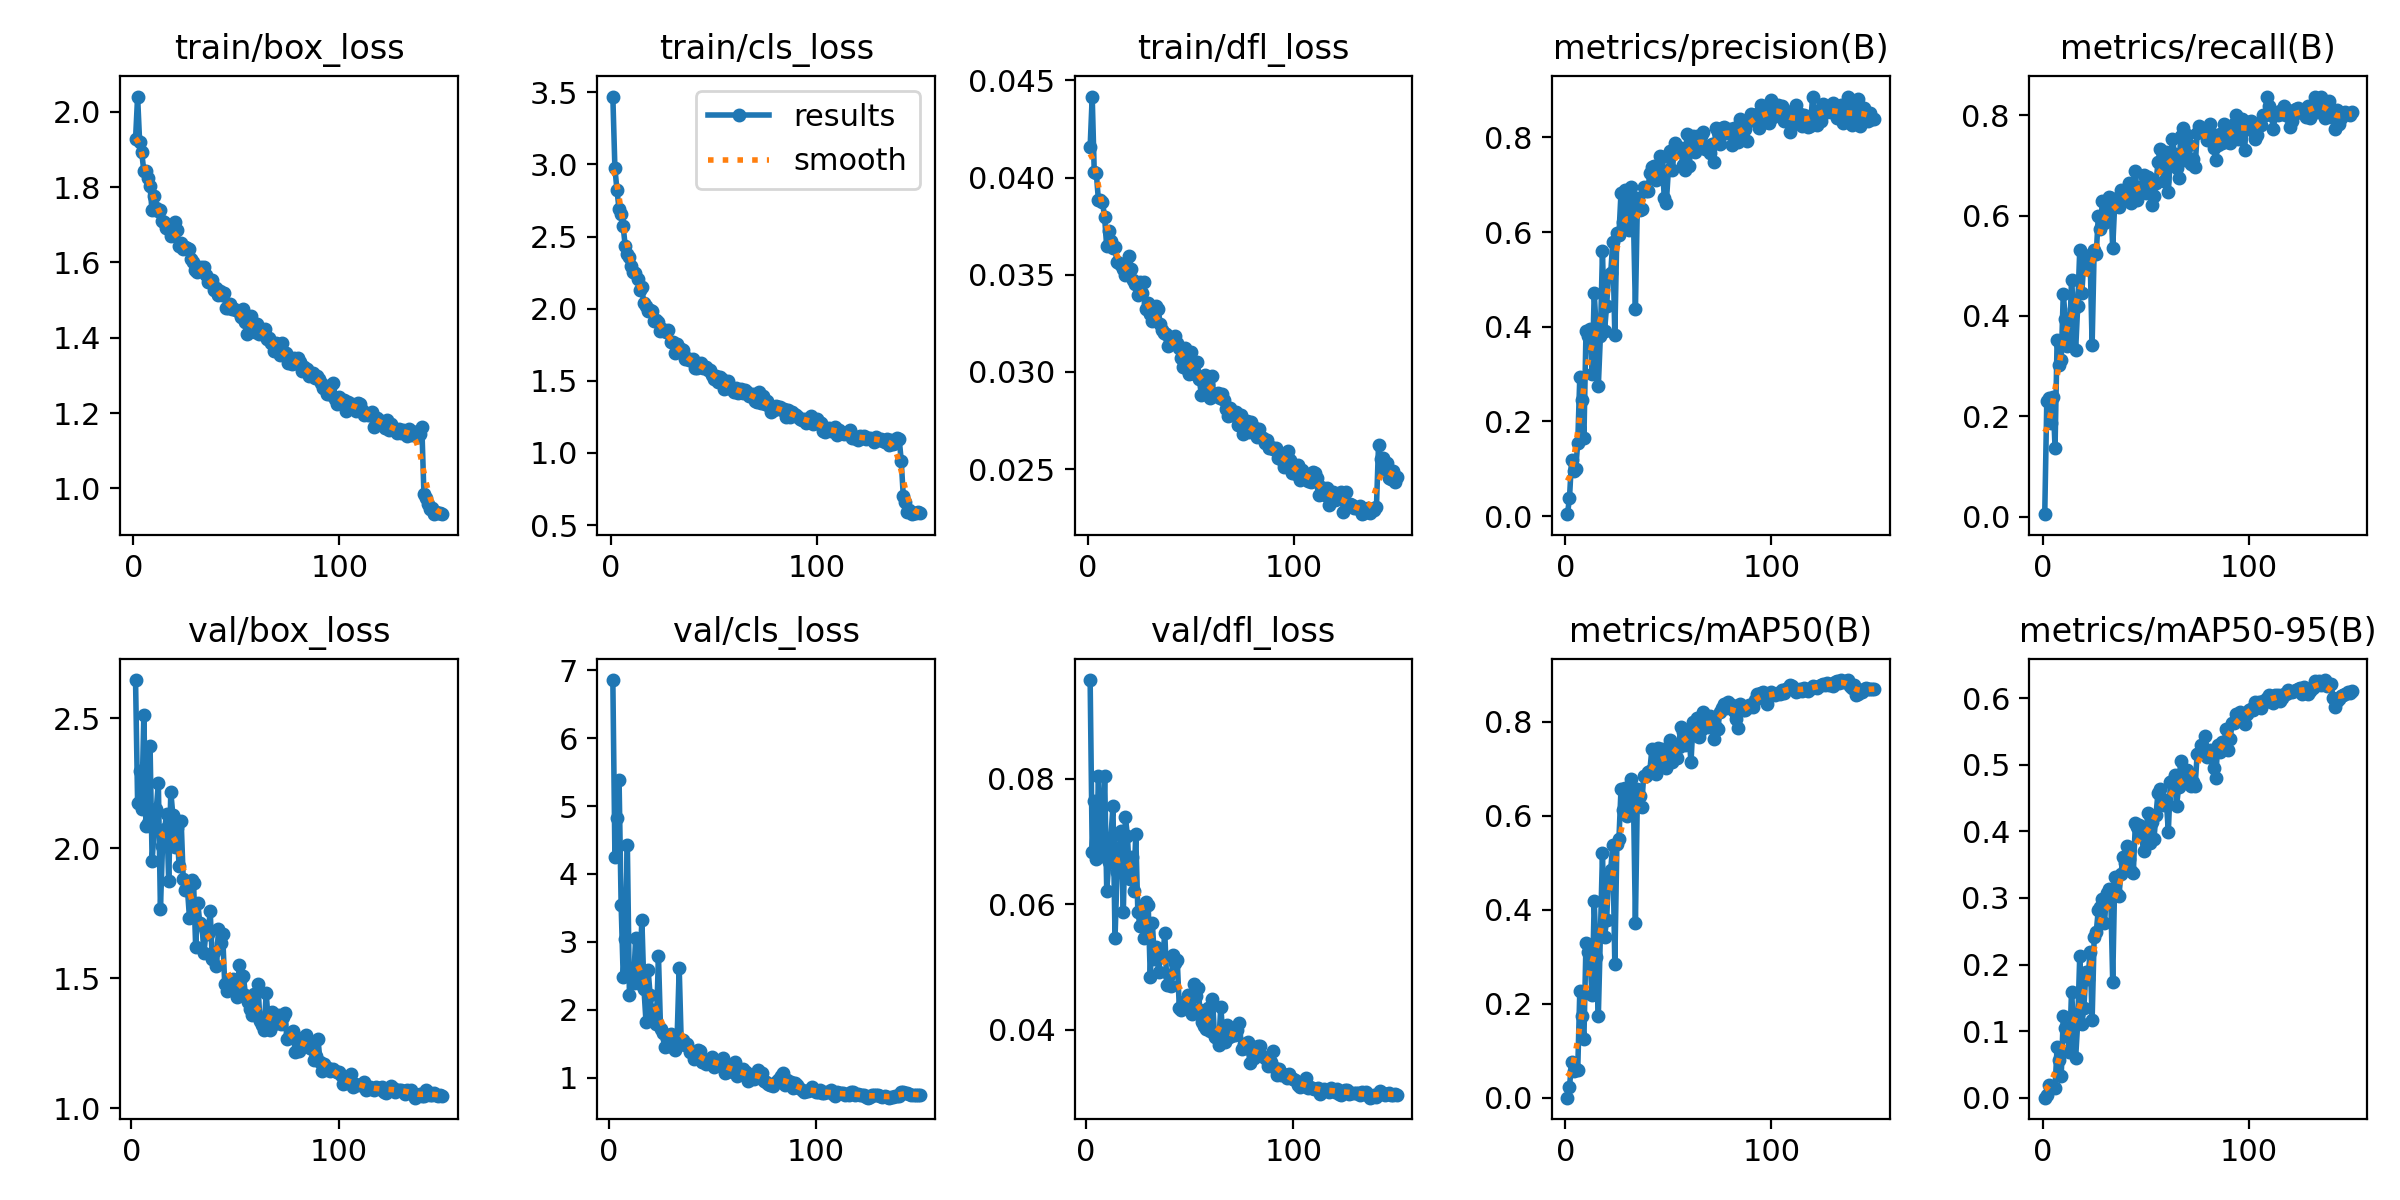


Run 2 Training Curves:


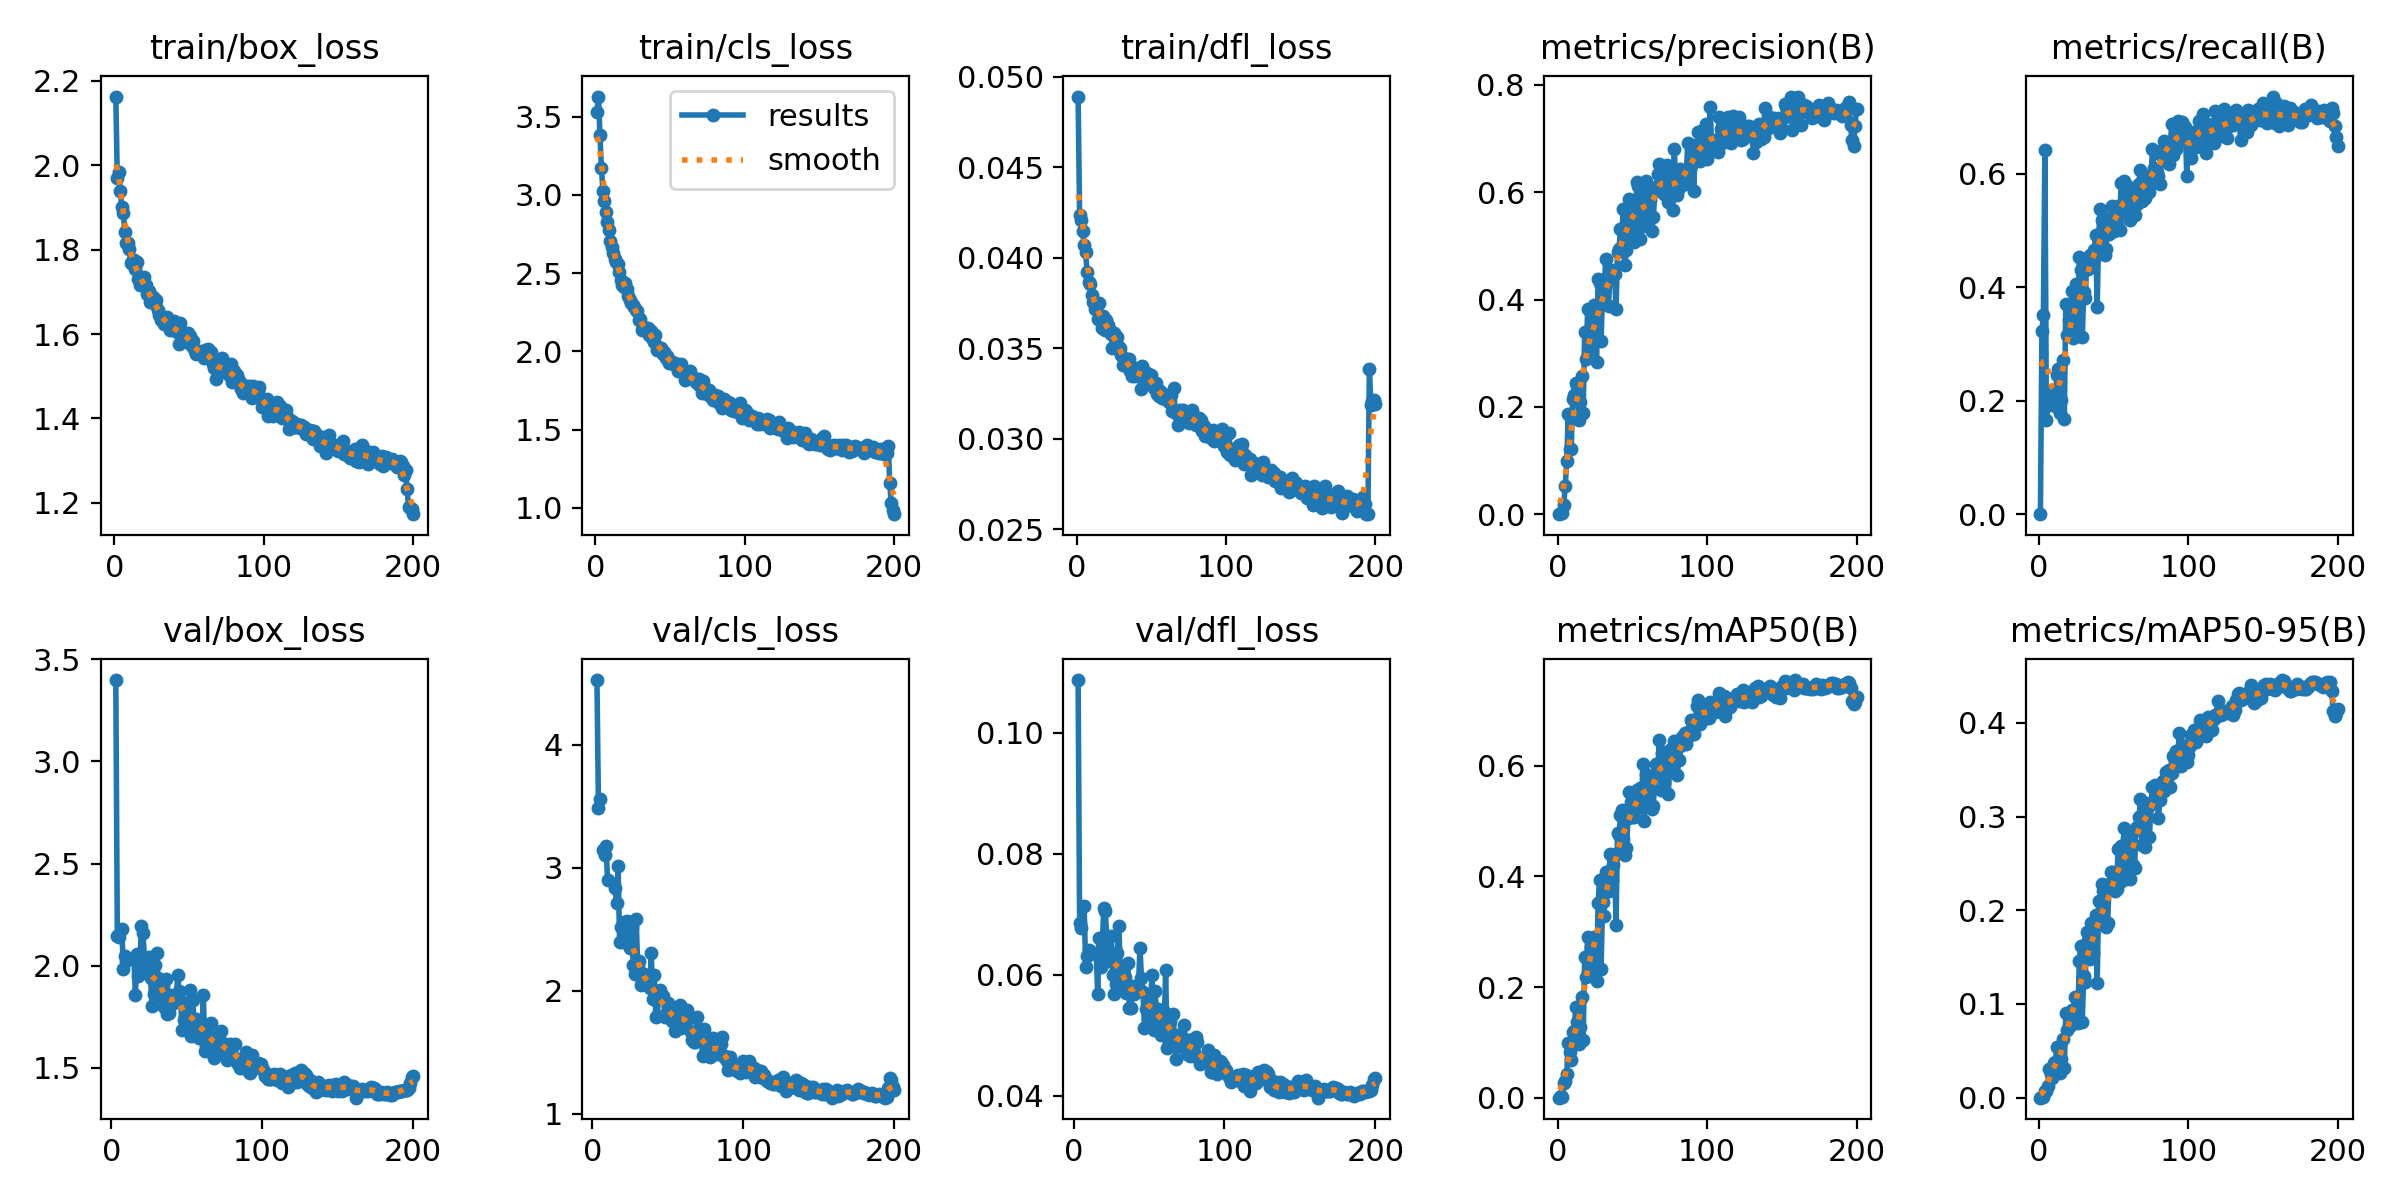

In [5]:
from ultralytics import YOLO
from IPython.display import Image, display
import os

best_model = YOLO('/content/runs/cats_v2_run1/weights/best.pt')

print('Evaluating best model (Run 1) on the holdout TEST split...')
test_metrics = best_model.val(data='/content/data/data.yaml', split='test')

print('\nRun 1 Training Curves:')
if os.path.exists('/content/runs/cats_v2_run1/results.png'):
    display(Image(filename='/content/runs/cats_v2_run1/results.png', width=800))

print('\nRun 2 Training Curves:')
if os.path.exists('/content/runs/cats_v2_run2/results.png'):
    display(Image(filename='/content/runs/cats_v2_run2/results.png', width=800))

### Comparison against Week-1 Baseline

All mAP values below are **validation-split** scores. Test-split scores for the best run are printed by the evaluation cell above.

> **Note on split comparability:** the Week-1 baseline was evaluated on the original photorealistic-only dataset. The v2 validation and test splits include 600 COCO hard-negative backgrounds — a harder distribution for false-positive suppression.

| Run | Backbone | Techniques | mAP\@0.5 (val) | mAP\@0.5:0.95 (val) | P | R |
|---|---|---|---|---|---|---|
| Week-1 baseline | yolo26s | none | 0.917 | 0.738 | 0.894 | 0.880 |
| Run 1 — Augmentation + cos\_lr (best) | yolo26m | mosaic, mixup, hsv, cos\_lr | 0.887 | 0.627 | 0.889 | 0.796 |
| Run 2 — Two-stage + extended | yolo26m | above + two-stage freeze, warmup\_epochs=0 | 0.748 | 0.447 | 0.772 | 0.679 |

### Why Run 1 Was Selected as Best

 Stage 2 of Run 2 failed to improve on Stage 1 (0.916 val mAP) because setting warmup_epochs=0 with lr0=0.01 on an already-converged checkpoint caused backbone destabilisation in the first unfreezing epochs. The model oscillated around 0.71–0.74 mAP for the full 200 epochs without recovering to Stage 1 levels. This is a known failure mode of two-stage training when the Stage 2 learning rate is not reduced relative to Stage 1. Run 1, trained end-to-end for 150 epochs on the clean dataset, converged stably to 0.887 and is the submission model.

### Exporting to ONNX

In [ ]:
!pip install -q 'onnx>=1.12.0,<2.0.0' onnxslim onnxruntime

import os
import random
import numpy as np
import onnxruntime as ort
from ultralytics import YOLO

print(f'onnxruntime version : {ort.__version__}')
print(f'Available providers : {ort.get_available_providers()}')

print('\nExporting Run 1 best model to ONNX...')
best_model = YOLO('/content/runs/cats_v2_run1/weights/best.pt')
onnx_path = best_model.export(
    format='onnx',
    imgsz=640,
    opset=17,
    dynamic=False
)
print(f'Export successful: {onnx_path}')

sess_check = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
out_shape = sess_check.get_outputs()[0].shape
print(f'ONNX output shape: {out_shape}  (expected: [1, 300, 6])')
assert len(out_shape) == 3 and out_shape[1] == 300 and out_shape[2] == 6, \
    f'Unexpected output shape {out_shape}. Export may have used non-e2e head.'
del sess_check

from PIL import Image as PILImage

def letterbox_np(img_path, target=640):
    img = PILImage.open(img_path).convert('RGB')
    orig_w, orig_h = img.size
    scale = min(target / orig_w, target / orig_h)
    new_w, new_h = int(round(orig_w * scale)), int(round(orig_h * scale))
    pad_w = (target - new_w) / 2.0
    pad_h = (target - new_h) / 2.0
    resized = img.resize((new_w, new_h), PILImage.Resampling.BILINEAR)
    padded = PILImage.new('RGB', (target, target), (114, 114, 114))
    padded.paste(resized, (int(round(pad_w)), int(round(pad_h))))
    x = (np.array(padded, dtype=np.float32) / 255.0).transpose(2, 0, 1)[None]
    return x, scale, pad_w, pad_h

ort_session = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
input_name  = ort_session.get_inputs()[0].name

test_dir    = '/content/data/DATA_CLEAN_V2/images/test'
all_imgs    = [f for f in os.listdir(test_dir)
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
sample_imgs = random.sample(all_imgs, min(5, len(all_imgs)))

print(f'\nNumerical tolerance check on {len(sample_imgs)} test images (conf=0.25):')
print(f'{"Image":<45} {"PT":>5} {"ONNX":>5} {"Max diff (px)":>14} {"Status":>8}')
print('-' * 82)

all_passed = True
for img_name in sample_imgs:
    img_path = os.path.join(test_dir, img_name)

    pt_res    = best_model.predict(img_path, imgsz=640, conf=0.25, verbose=False)[0]
    pt_boxes  = pt_res.boxes.xyxy.cpu().numpy()

    x, scale, pad_w, pad_h = letterbox_np(img_path)
    raw_out   = ort_session.run(None, {input_name: x})[0][0]
    onnx_dets = [(r[0], r[1], r[2], r[3], r[4], r[5])
                 for r in raw_out if r[4] >= 0.25]
    img_tmp   = PILImage.open(img_path)
    orig_w, orig_h = img_tmp.size
    onnx_boxes_list = []
    for x1, y1, x2, y2, score, cls in onnx_dets:
        x1 = max(0.0, min(orig_w, (x1 - pad_w) / scale))
        y1 = max(0.0, min(orig_h, (y1 - pad_h) / scale))
        x2 = max(0.0, min(orig_w, (x2 - pad_w) / scale))
        y2 = max(0.0, min(orig_h, (y2 - pad_h) / scale))
        onnx_boxes_list.append([x1, y1, x2, y2])
    onnx_boxes = np.array(onnx_boxes_list) if onnx_boxes_list else np.zeros((0, 4))

    n_pt, n_onnx = len(pt_boxes), len(onnx_boxes)

    if n_pt == n_onnx and n_pt > 0:
        max_diff = float(np.abs(pt_boxes - onnx_boxes).max())
        passed   = max_diff < 1.0
    elif n_pt == 0 and n_onnx == 0:
        max_diff, passed = 0.0, True
    else:
        max_diff, passed = float('inf'), False

    if not passed:
        all_passed = False

    diff_str = f'{max_diff:.4f}' if max_diff != float('inf') else 'count mismatch'
    status   = 'PASS' if passed else 'FAIL'
    print(f'{img_name:<45} {n_pt:>5} {n_onnx:>5} {diff_str:>14} {status:>8}')

print('-' * 82)
if all_passed:
    print('\nAll sanity checks passed: ONNX output matches PyTorch within 1-pixel tolerance.')
else:
    print('\nWarning: some checks failed. Review the diff values above.')
    print('Note: small count mismatches near conf=0.25 threshold are expected due to')
    print('NMS score rounding differences. The container uses conf=0.05 which is more stable.')

onnxruntime version : 1.26.0
Available providers : ['AzureExecutionProvider', 'CPUExecutionProvider']

Exporting Run 1 best model to ONNX...
Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
YOLO26m summary (fused): 132 layers, 20,350,223 parameters, 0 gradients, 67.8 GFLOPs

PyTorch: starting from '/content/runs/cats_v2_run1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (42.0 MB)

ONNX: starting export with onnx 1.21.0 opset 17...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 2.9s, saved as '/content/runs/cats_v2_run1/weights/best.onnx' (77.9 MB)

Export complete (3.7s)
Results saved to /content/runs/cats_v2_run1/weights/best.onnx
Predict:         yolo predict task=detect model=/content/runs/cats_v2_run1/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/runs/cats_v2_run1/weights/best.onnx imgsz=640 data=/content/data/data.yaml  
Visualize:       https://netron.

## Part B — Containerise the Inference

The cells below programmatically generate the complete `container/` directory structure: Dockerfile, STUDENT.json, requirements.txt, `app/__init__.py`, `app/detector.py`, and `app/cli.py`. All files conform exactly to the standardised CLI specification.

### Container Directory Structure and ONNX Copy

In [ ]:
import os
import shutil

CONTAINER_DIR = "/content/container"
APP_DIR = os.path.join(CONTAINER_DIR, "app")
MODELS_DIR = os.path.join(CONTAINER_DIR, "models")

os.makedirs(APP_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

onnx_source = "/content/runs/cats_v2_run1/weights/best.onnx"
onnx_dest = os.path.join(MODELS_DIR, "best.onnx")

if os.path.exists(onnx_source):
    shutil.copy(onnx_source, onnx_dest)
    print("Container directory structure created and ONNX model safely copied to /models.")
else:
    print("ONNX model not found. Ensure the export cell ran successfully.")

Container directory structure created and ONNX model safely copied to /models.


### Configuration Files

In [ ]:
import json, os

CONTAINER_DIR = '/content/container'

student_data = {
    'first_name': 'Ali',
    'last_name': 'Aligulu',
    'team': 'ali-aligulu',
    'model': {
        'framework': 'yolo26',
        'variant': 'yolo26m',
        'imgsz': 640,
        'epochs_total': 150,
        'tricks': ['mosaic', 'mixup', 'cos_lr', 'hsv_tuning', 'hard_negatives_600']
    },
    'notes': '3927-pair dataset: 3327 photorealistic cats + 600 COCO hard-negatives. Run 1 selected as best: 150 epochs, mAP@0.5=0.887 val. Run 2 two-stage training did not recover after backbone unfreezing due to lr0=0.01 being too aggressive on an already-converged Stage 1 checkpoint. erasing=0.0 for training stability.'
}
with open(os.path.join(CONTAINER_DIR, 'STUDENT.json'), 'w') as f:
    json.dump(student_data, f, indent=4)

req = 'onnxruntime==1.26.0\nnumpy\npillow\nopencv-python-headless\n'
with open(os.path.join(CONTAINER_DIR, 'requirements.txt'), 'w') as f:
    f.write(req)

dockerfile = (
    'FROM python:3.11-slim\n\n'
    'WORKDIR /app\n\n'
    'COPY container/requirements.txt /app/requirements.txt\n'
    'RUN pip install --no-cache-dir -r /app/requirements.txt\n\n'
    'COPY container/app /app/app\n'
    'COPY container/models /app/models\n'
    'COPY container/STUDENT.json /app/STUDENT.json\n\n'
    'ENTRYPOINT ["python", "/app/app/cli.py"]\n'
)
with open(os.path.join(CONTAINER_DIR, 'Dockerfile'), 'w') as f:
    f.write(dockerfile)

print('STUDENT.json, requirements.txt, and Dockerfile successfully generated.')
print('Tricks:', student_data['model']['tricks'])

STUDENT.json, requirements.txt, and Dockerfile successfully generated.
Tricks: ['mosaic', 'mixup', 'cos_lr', 'hsv_tuning', 'hard_negatives_600']


### Inference Logic

In [ ]:
import os

APP_DIR = '/content/container/app'

with open(os.path.join(APP_DIR, '__init__.py'), 'w') as f:
    f.write('')

detector_content = 'import numpy as np\nimport onnxruntime as ort\nfrom PIL import Image\n\n\nclass CatDetector:\n    def __init__(self, onnx_path, imgsz=640, conf=0.05, class_names=("cat",)):\n        self.session = ort.InferenceSession(\n            onnx_path, providers=["CPUExecutionProvider"]\n        )\n        self.imgsz = imgsz\n        self.conf = conf\n        self.class_names = class_names\n        self.input_name = self.session.get_inputs()[0].name\n\n    def _letterbox(self, img, target_size):\n        orig_w, orig_h = img.size\n        scale = min(target_size / orig_w, target_size / orig_h)\n        new_w = int(round(orig_w * scale))\n        new_h = int(round(orig_h * scale))\n        pad_w = (target_size - new_w) / 2.0\n        pad_h = (target_size - new_h) / 2.0\n        resized = img.resize((new_w, new_h), Image.Resampling.BILINEAR)\n        padded = Image.new("RGB", (target_size, target_size), (114, 114, 114))\n        padded.paste(resized, (int(round(pad_w)), int(round(pad_h))))\n        return padded, scale, (pad_w, pad_h)\n\n    def predict(self, image_path: str) -> list:\n        img = Image.open(image_path).convert("RGB")\n        orig_w, orig_h = img.size\n\n        x, scale, (pad_x, pad_y) = self._letterbox(img, self.imgsz)\n        x = (np.array(x, dtype=np.float32) / 255.0).transpose(2, 0, 1)[None]\n\n        # YOLO26 e2e output: (1, 300, 6) -> [x1, y1, x2, y2, score, class]\n        out = self.session.run(None, {self.input_name: x})[0][0]\n\n        results = []\n        for x1, y1, x2, y2, score, cls in out:\n            if score < self.conf:\n                continue\n            x1 = max(0.0, min(orig_w, (x1 - pad_x) / scale))\n            y1 = max(0.0, min(orig_h, (y1 - pad_y) / scale))\n            x2 = max(0.0, min(orig_w, (x2 - pad_x) / scale))\n            y2 = max(0.0, min(orig_h, (y2 - pad_y) / scale))\n            results.append({\n                "xmin": float(x1), "ymin": float(y1),\n                "xmax": float(x2), "ymax": float(y2),\n                "confidence": float(score),\n                "class": self.class_names[int(cls)],\n            })\n        return results\n'
with open(os.path.join(APP_DIR, 'detector.py'), 'w') as f:
    f.write(detector_content)

cli_content = 'import sys\nimport os\nimport json\nimport csv\nfrom pathlib import Path\n\n# Ensure the directory containing this script is on the path.\n# Required so Docker can resolve `from detector import CatDetector`\n# when the ENTRYPOINT is `python /app/app/cli.py`.\nsys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))\nfrom detector import CatDetector\n\n\ndef cmd_info():\n    student_file = Path("/app/STUDENT.json")\n    if student_file.exists():\n        print(student_file.read_text())\n    else:\n        print(json.dumps({"error": "STUDENT.json not found"}))\n        sys.exit(1)\n\n\ndef cmd_predict():\n    input_dir  = Path("/data/input")\n    output_csv = Path("/data/output/predictions.csv")\n    output_csv.parent.mkdir(parents=True, exist_ok=True)\n\n    detector   = CatDetector("/app/models/best.onnx", imgsz=640, conf=0.05)\n    valid_exts = {".jpg", ".jpeg", ".png", ".webp",\n                  ".JPG", ".JPEG", ".PNG", ".WEBP"}\n\n    with open(output_csv, mode="w", newline="", encoding="utf-8") as f:\n        writer = csv.writer(f)\n        writer.writerow([\n            "image_path", "xmin", "ymin", "xmax", "ymax",\n            "confidence", "class"\n        ])\n        for img_path in sorted(input_dir.rglob("*")):\n            if not (img_path.is_file() and\n                    img_path.suffix in valid_exts):\n                continue\n            rel_path = img_path.relative_to(input_dir).as_posix()\n            try:\n                preds = detector.predict(str(img_path))\n                if not preds:\n                    writer.writerow([rel_path, "", "", "", "", "", ""])\n                else:\n                    for p in preds:\n                        writer.writerow([\n                            rel_path,\n                            round(p["xmin"], 4),\n                            round(p["ymin"], 4),\n                            round(p["xmax"], 4),\n                            round(p["ymax"], 4),\n                            round(p["confidence"], 4),\n                            p["class"],\n                        ])\n            except Exception:\n                writer.writerow([rel_path, "", "", "", "", "", ""])\n\n\nif __name__ == "__main__":\n    if len(sys.argv) < 2:\n        sys.exit(1)\n    cmd = sys.argv[1].lower()\n    if cmd == "info":\n        cmd_info()\n    elif cmd == "predict":\n        cmd_predict()\n    else:\n        sys.exit(1)\n'
with open(os.path.join(APP_DIR, 'cli.py'), 'w') as f:
    f.write(cli_content)

print('detector.py and cli.py successfully generated.')
print('Verifying sys.path.insert present in cli.py:', 'sys.path.insert' in cli_content)

detector.py and cli.py successfully generated.
Verifying sys.path.insert present in cli.py: True


## Zipping and Downloading Final Project Content

In [ ]:
import os
import shutil

MASTER_BUNDLE = "/content/final_project_bundle"

if os.path.exists(MASTER_BUNDLE):
    shutil.rmtree(MASTER_BUNDLE)

os.makedirs(MASTER_BUNDLE, exist_ok=True)

if os.path.exists("/content/container"):
    shutil.copytree("/content/container", os.path.join(MASTER_BUNDLE, "container"))

if os.path.exists("/content/runs"):
    shutil.copytree("/content/runs", os.path.join(MASTER_BUNDLE, "runs"))

if os.path.exists("/content/data/data.yaml"):
    shutil.copy("/content/data/data.yaml", os.path.join(MASTER_BUNDLE, "data.yaml"))

!cd /content && zip -r -q final_project_bundle.zip final_project_bundle/
print("'final_project_bundle.zip' is ready for download in the file browser.")

'final_project_bundle.zip' is ready for download in the file browser.
